In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
'''PRÉ DEFINIÇÕES INICIAIS PARA ORGANIZAÇÃO DOS DADOS'''

# Arquivo de 2025 para base de aprendizado
df_treino = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2025_A_31-12-2025.CSV", # Lê o arquivo CSV
                        sep=';', # define o ponto e vírgula como separador de colunas
                        encoding='latin-1', # resolve problemas de acentuação comuns em arquivos brasileiros
                        skiprows=8, # pula as linhas iniciais do cabeçalho administrativo
                        decimal=',') # converte números como "15,5" para 15.5 (float)

# Arquivo de 2026 para validar o modelo depois
df_teste = pd.read_csv("INMET_S_PR_A807_CURITIBA_01-01-2026_A_28-02-2026.CSV", sep=';', encoding='latin-1', skiprows=8, decimal=',')

# Exibir colunas e primeiras linhas
display(df_treino.head())

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19
0,2025/01/01,0000 UTC,0.0,911.1,911.1,910.2,NaN,20.3,18.3,20.4,20.2,18.6,18.1,90.0,88.0,89.0,77.0,5.2,2.0,NaN
1,2025/01/01,0100 UTC,0.0,911.7,911.8,911.1,NaN,20.0,18.1,20.4,20.0,18.6,17.9,89.0,88.0,89.0,84.0,5.5,3.0,NaN
2,2025/01/01,0200 UTC,0.0,911.4,911.7,911.3,NaN,19.7,18.1,20.0,19.6,18.3,18.0,91.0,89.0,90.0,92.0,6.0,2.4,NaN
3,2025/01/01,0300 UTC,0.0,911.3,911.4,911.2,NaN,19.7,18.0,19.8,19.7,18.2,17.9,91.0,90.0,90.0,78.0,5.8,2.7,NaN
4,2025/01/01,0400 UTC,0.0,911.0,911.3,911.0,NaN,19.4,18.0,19.7,19.4,18.1,17.9,92.0,90.0,92.0,77.0,6.3,2.3,NaN


Sistema de Classificação

In [3]:
# Substitui o valor de erro (-9999) por "NaN" nos dois DataFrames
df_treino = df_treino.replace(-9999, np.nan)
df_teste = df_teste.replace(-9999, np.nan)

# Criação da coluna alvo 'CHUVA' (0 ou 1) com base na precipitação antes de excluí-la
df_treino['CHUVA'] = (df_treino['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0).astype(int)
df_teste['CHUVA'] = (df_teste['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0).astype(int)

#Separar apenas as colunas importantes para analisar possibilidade de chuva
col_temp = 'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)'
col_umid = 'UMIDADE RELATIVA DO AR, HORARIA (%)'
col_pres = 'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)'
col_rad  = 'RADIACAO GLOBAL (Kj/m²)'

features = [col_temp, col_umid, col_pres, col_rad]

#Variável alvo original
col_chuva = 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'
# Verificação de segurança

print(f"Total de registros para treino: {len(df_treino)}") #quantidade antes de limpar linhas vazias
print(f"Total de registros para teste: {len(df_teste)}")

Total de registros para treino: 8760
Total de registros para teste: 1416


In [4]:
# Cria uma cópia que remove linhas com valores nulos (NaN)
df_treino_limpo = df_treino[features + ['CHUVA']].dropna()
df_teste_limpo = df_teste[features + ['CHUVA']].dropna()

# Features / Target -> Arquivo de treino
X_train = df_treino_limpo[features]
y_train = df_treino_limpo['CHUVA']

# Features / Target -> Arquivo de teste
X_test = df_teste_limpo[features]
y_test = df_teste_limpo['CHUVA']

# Escalonamento - para que todas as colunas tenham uma média próxima de 0 e um desvio padrão de 1)
scaler = StandardScaler()

# Aplica scaler em ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Verificação de segurança
print(f"Total de registros para treino: {len(X_train_scaled)}") #quantidade após limpar linhas vazias
print(f"Total de registros para teste: {len(X_test_scaled)}")

Total de registros para treino: 4930
Total de registros para teste: 936


In [5]:
# Modelo de Regressão Logística
modelo_logistica = LogisticRegression()

# Treina o modelo usando os dados de 2025 (X_train_scaled e y_train)
modelo_logistica.fit(X_train_scaled, y_train)

# Faz as previsões usando os dados de 2026 (X_test_scaled)
previsoes_logistica = modelo_logistica.predict(X_test_scaled)

print("Primeiro modelo, OK")

Primeiro modelo, OK


              precision    recall  f1-score   support

           0       0.90      0.98      0.94       835
           1       0.41      0.12      0.18       101

    accuracy                           0.89       936
   macro avg       0.66      0.55      0.56       936
weighted avg       0.85      0.89      0.86       936

Acurácia Total: 88.68%


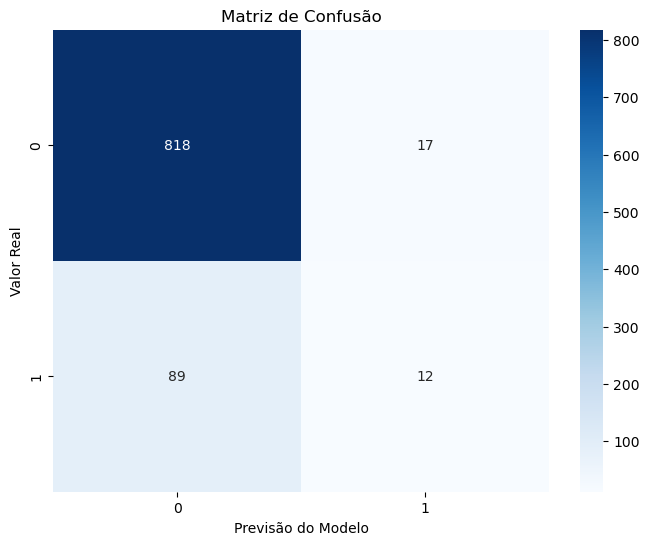

In [6]:
# Matriz de Confusão
matriz = confusion_matrix(y_test, previsoes_logistica)

# Exibe as métricas principais (Acurácia, Precisão, Recall, F1-Score)
print(classification_report(y_test, previsoes_logistica))

# Exibe a Acurácia total
acuracia = accuracy_score(y_test, previsoes_logistica)
print(f"Acurácia Total: {acuracia:.2%}")

# Relatório da Matriz
plt.figure(figsize=(8,6))
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

In [7]:
# Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(max_depth=5, random_state=42)

# Treina o modelo
modelo_arvore.fit(X_train_scaled, y_train)

# Faz as previsões para 2026
previsoes_arvore = modelo_arvore.predict(X_test_scaled)

# Relatório
print(classification_report(y_test, previsoes_arvore))

              precision    recall  f1-score   support

           0       0.90      0.97      0.93       835
           1       0.29      0.10      0.15       101

    accuracy                           0.88       936
   macro avg       0.60      0.54      0.54       936
weighted avg       0.83      0.88      0.85       936



In [8]:
# Modelo de Random Forest
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42) # n_estimators=100 significa que criaremos 100 árvores para votarem

# Treina o modelo
modelo_rf.fit(X_train_scaled, y_train)

# Faz as previsões para 2026
previsoes_rf = modelo_rf.predict(X_test_scaled)

# Relatório
print(classification_report(y_test, previsoes_rf))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       835
           1       0.49      0.18      0.26       101

    accuracy                           0.89       936
   macro avg       0.70      0.58      0.60       936
weighted avg       0.86      0.89      0.87       936



In [9]:
# 1Modelo KNN
modelo_knn = KNeighborsClassifier(n_neighbors=5) # n_neighbors=5 significa que ele olha os 5 vizinhos mais próximos

# Treina o modelo
modelo_knn.fit(X_train_scaled, y_train)

# Faz as previsões para 2026
previsoes_knn = modelo_knn.predict(X_test_scaled)

# Relatório
print(classification_report(y_test, previsoes_knn))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       835
           1       0.33      0.09      0.14       101

    accuracy                           0.88       936
   macro avg       0.62      0.53      0.54       936
weighted avg       0.84      0.88      0.85       936



C:\Users\desyr\AppData\Local\Temp\ipykernel_36608\3098128972.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Modelo', y='Acurácia', data=df_grafico, palette='viridis')


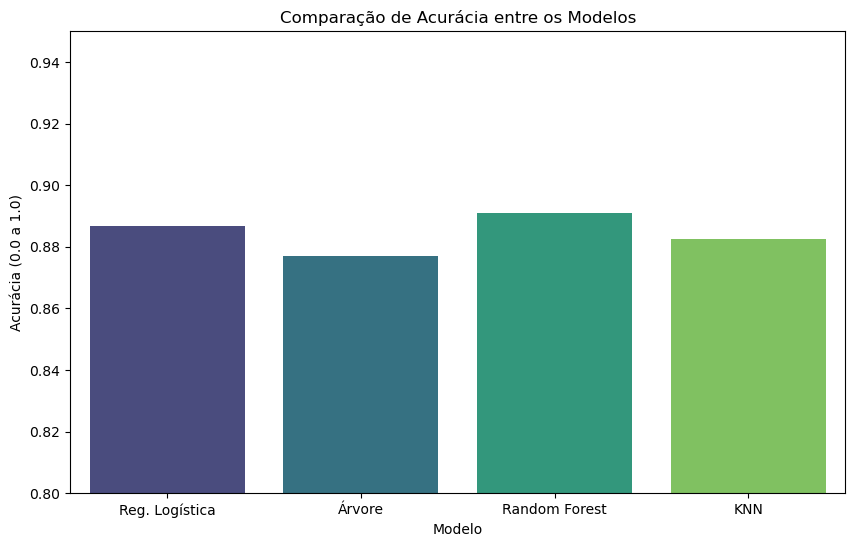

In [10]:
# Cria um dicionário com os resultados de acurácia
resultados = {
    'Reg. Logística': accuracy_score(y_test, previsoes_logistica),
    'Árvore': accuracy_score(y_test, previsoes_arvore),
    'Random Forest': accuracy_score(y_test, previsoes_rf),
    'KNN': accuracy_score(y_test, previsoes_knn)
}

# Transforma em DataFrame para facilitar o gráfico
df_grafico = pd.DataFrame(list(resultados.items()), columns=['Modelo', 'Acurácia'])

# Cria o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x='Modelo', y='Acurácia', data=df_grafico, palette='viridis')
plt.ylim(0.8, 0.95) # Zoom para ver melhor a diferença
plt.title('Comparação de Acurácia entre os Modelos')
plt.ylabel('Acurácia (0.0 a 1.0)')
plt.show()

In [19]:
#Cria função de previsão de chuva

def prever_chuva_manual():
    print("Previsão de Chuva")
    temp = float(input("Digite a Temperatura (°C): "))
    umid = float(input("Digite a Umidade (%): "))
    pres = float(input("Digite a Pressão (mB): "))
    radi = float(input("Digite a Radiação (Kj/m²): "))
    
    # Criar um array com as entradas
    entrada = np.array([[temp, umid, pres, radi]])
    
    # Escalonar a entrada igual no treino
    entrada_scaled = scaler.transform(entrada)
    
    # Fazer a previsão com o melhor modelo (Random Forest)
    resultado = modelo_rf.predict(entrada_scaled)

    print("Temperatura ", temp)
    print("Umidade ", umid)
    print("Pressão  ", pres)
    print("Radiação  ", radi)
    
    if resultado[0] == 1:
        print("\nResultado: PREVISÃO DE CHUVA!")

    else:
        print("\nResultado: SEM CHUVA.")

# Para testar, basta chamar a função:
prever_chuva_manual()

Previsão de Chuva
Temperatura  10.0
Umidade  90.0
Pressão   800.0
Radiação   20.0

Resultado: PREVISÃO DE CHUVA!


c:\Users\desyr\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


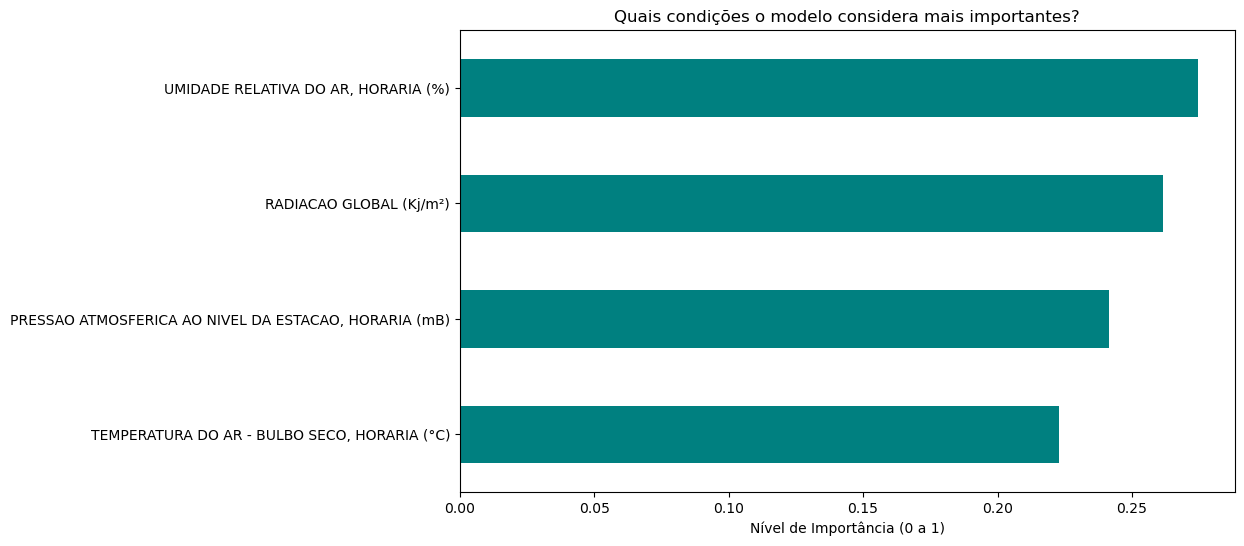

In [ ]:
# Importância das colunas do melhor modelo
importancias = pd.Series(modelo_rf.feature_importances_, index=features)

# Criando o gráfico
plt.figure(figsize=(10, 6))
importancias.sort_values().plot(kind='barh', color='teal')
plt.title('Quais condições o modelo considera mais importantes?')
plt.xlabel('Nível de Importância (0 a 1)')
plt.show()